In [1]:
# ================================================
# SETUP
# ================================================
!pip install transformers datasets biopython einops torch torchvision torchaudio
!pip install git+https://github.com/facebookresearch/esm.git  # for ESM2

import torch, requests
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 73.5 MB/s eta 0:00:00
  Cloning https://github.com/facebookresearch/esm.git to /tmp/pip-req-build-yyx55q9w
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/esm.git /tmp/pip-req-build-yyx55q9w
  Resolved https://github.com/facebookresearch/esm.git to commit 2b369911bb5b4b0dda914521b9475cad1656b2ac
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fair-esm: filename=fair_esm-2.0.1-py3-none-any.whl size=105450 sha256=eb0272c938ae757d37c7d5b48625dac15464c9cb987d26ea2272d736239b3c4d
  Stored in directory: /tmp/pip-ephem-wheel-cache-g2t5uiv0/wheels/be/59/a3/3c629ec827b5f86d4003a343b8c6e5b62b431b3daa1998e32c
Successfully built fair-esm


In [3]:
# ================================================
# 1. Load ESM2 Model
# ================================================
from esm import pretrained
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load pretrained ESM2 (650M version is feasible in Colab)
esm_model, alphabet = pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()

# ================================================
# 2. Define Sequences (WNT5A, ROR2, FZD1–FZD9)
# Replace (...) with full sequences from UniProt
# ================================================
seqs = [
    ("WNT5A", "MKKSIGILSPGVALGMAGSAMSSKFFLVALAIFFSFAQVVIEANSWWSLGMNNPVQMSEVYIIGAQPLCSQLAGLSQGQKKLCHLYQDHMQYIGEGAKTGIKECQYQFRHRRWNCSTVDNTSVFGRVMQIGSRETAFTYAVSAAGVVNAMSRACREGELSTCGCSRAARPKDLPRDWLWGGCGDNIDYGYRFAKEFVDARERERIHAKGSYESARILMNLHNNEAGRRTVYNLADVACKCHGVSGSCSLKTCWLQLADFRKVGDALKEKYDSAAAMRLNSRGKLVQVNSRFNSPTTQDLVYIDPSPDYCVRNESTGSLGTQGRLCNKTSEGMDGCELMCCGRGYDQFKTVQTERCHCKFHWCCYVKCKKCTEIVDQFVCK"),
    ("ROR2", "MARGSALPRRPLLCIPAVWAAAALLLSVSRTSGEVEVLDPNDPLGPLDGQDGPIPTLKGYFLNFLEPVNNITIVQGQTAILHCKVAGNPPPNVRWLKNDAPVVQEPRRIIIRKTEYGSRLRIQDLDTTDTGYYQCVATNGMKTITATGVLFVRLGPTHSPNHNFQDDYHEDGFCQPYRGIACARFIGNRTIYVDSLQMQGEIENRITAAFTMIGTSTHLSDQCSQFAIPSFCHFVFPLCDARSRTPKPRELCRDECEVLESDLCRQEYTIARSNPLILMRLQLPKCEALPMPESPDAANCMRIGIPAERLGRYHQCYNGSGMDYRGTASTTKSGHQCQPWALQHPHSHHLSSTDFPELGGGHAYCRNPGGQMEGPWCFTQNKNVRMELCDVPSCSPRDSSKMGILYILVPSIAIPLVIACLFFLVCMCRNKQKASASTPQRRQLMASPSQDMEMPLINQHKQAKLKEISLSAVRFMEELGEDRFGKVYKGHLFGPAPGEQTQAVAIKTLKDKAEGPLREEFRHEAMLRARLQHPNVVCLLGVVTKDQPLSMIFSYCSHGDLHEFLVMRSPHSDVGSTDDDRTVKSALEPPDFVHLVAQIAAGMEYLSSHHVVHKDLATRNVLVYDKLNVKISDLGLFREVYAADYYKLLGNSLLPIRWMAPEAIMYGKFSIDSDIWSYGVVLWEVFSYGLQPYCGYSNQDVVEMIRNRQVLPCPDDCPAWVYALMIECWNEFPSRRPRFKDIHSRLRAWGNLSNYNSSAQTSGASNTTQTSSLSTSPVSNVSNARYVGPKQKAPPFPQPQFIPMKGQIRPMVPPPQLYVPVNGYQPVPAYGAYLPNFYPVQIPMQMAPQQVPPQMVPKPSSHHSGSGSTSTGYVTTAPSNTSMADRAALLSEGADDTQNAPEDGAQSTVQEAEEEEEGSVPETELLGDCDTLQVDEAQVQLEA"),
    ("FZD1", "MAEEEAPKKSRAAGGGASWELCAGALSARLAEEGSGDAGGRRRPPVDPRRLARQLLLLLWLLEAPLLLGVRAQAAGQGPGQGPGPGQQPPPPPQQQQSGQQYNGERGISVPDHGYCQPISIPLCTDIAYNQTIMPNLLGHTNQEDAGLEVHQFYPLVKVQCSAELKFFLCSMYAPVCTVLEQALPPCRSLCERARQGCEALMNKFGFQWPDTLKCEKFPVHGAGELCVGQNTSDKGTPTPSLLPEFWTSNPQHGGGGHRGGFPGGAGASERGKFSCPRALKVPSYLNYHFLGEKDCGAPCEPTKVYGLMYFGPEELRFSRTWIGIWSVLCCASTLFTVLTYLVDMRRFSYPERPIIFLSGCYTAVAVAYIAGFLLEDRVVCNDKFAEDGARTVAQGTKKEGCTILFMMLYFFSMASSIWWVILSLTWFLAAGMKWGHEAIEANSQYFHLAAWAVPAIKTITILALGQVDGDVLSGVCFVGLNNVDALRGFVLAPLFVYLFIGTSFLLAGFVSLFRIRTIMKHDGTKTEKLEKLMVRIGVFSVLYTVPATIVIACYFYEQAFRDQWERSWVAQSCKSYAIPCPHLQAGGGAPPHPPMSPDFTVFMIKYLMTLIVGITSGFWIWSGKTLNSWRKFYTRLTNSKQGETTV"),
    ("FZD2", "MRPRSALPRLLLPLLLLPAAGPAQFHGEKGISIPDHGFCQPISIPLCTDIAYNQTIMPNLLGHTNQEDAGLEVHQFYPLVKVQCSPELRFFLCSMYAPVCTVLEQAIPPCRSICERARQGCEALMNKFGFQWPERLRCEHFPRHGAEQICVGQNHSEDGAPALLTTAPPPGLQPGAGGTPGGPGGGGAPPRYATLEHPFHCPRVLKVPSYLSYKFLGERDCAAPCEPARPDGSMFFSQEETRFARLWILTWSVLCCASTFFTVTTYLVDMQRFRYPERPIIFLSGCYTMVSVAYIAGFVLQERVVCNERFSEDGYRTVVQGTKKEGCTILFMMLYFFSMASSIWWVILSLTWFLAAGMKWGHEAIEANSQYFHLAAWAVPAVKTITILAMGQIDGDLLSGVCFVGLNSLDPLRGFVLAPLFVYLFIGTSFLLAGFVSLFRIRTIMKHDGTKTEKLERLMVRIGVFSVLYTVPATIVIACYFYEQAFREHWERSWVSQHCKSLAIPCPAHYTPRMSPDFTVYMIKYLMTLIVGITSGFWIWSGKTLHSWRKFYTRLTNSRHGETTV"),
    ("FZD3", "MAMTWIVFSLWPLTVFMGHIGGHSLFSCEPITLRMCQDLPYNTTFMPNLLNHYDQQTAALAMEPFHPMVNLDCSRDFRPFLCALYAPICMEYGRVTLPCRRLCQRAYSECSKLMEMFGVPWPEDMECSRFPDCDEPYPRLVDLNLAGEPTEGAPVAVQRDYGFWCPRELKIDPDLGYSFLHVRDCSPPCPNMYFRREELSFARYFIGLISIICLSATLFTFLTFLIDVTRFRYPERPIIFYAVCYMMVSLIFFIGFLLEDRVACNASIPAQYKASTVTQGSHNKACTMLFMILYFFTMAGSVWWVILTITWFLAAVPKWGSEAIEKKALLFHASAWGIPGTLTIILLAMNKIEGDNISGVCFVGLYDVDALRYFVLAPLCLYVVVGVSLLLAGIISLNRVRIEIPLEKENQDKLVKFMIRIGVFSILYLVPLLVVIGCYFYEQAYRGIWETTWIQERCREYHIPCPYQVTQMSRPDLILFLMKYLMALIVGIPSVFWVGSKKTCFEWASFFHGRRKKEIVNESRQVLQEPDFAQSLLRDPNTPIIRKSRGTSTQGTSTHASSTQLAMVDDQRSKAGSIHSKVSSYHGSLHRSRDGRYTPCSYRGMEERLPHGSMSRLTDHSRHSSSHRLNEQSRHSSIRDLSNNPMTHITHGTSMNRVIEEDGTSA"),
    ("FZD4", "MAWRGAGPSVPGAPGGVGLSLGLLLQLLLLLGPARGFGDEEERRCDPIRISMCQNLGYNVTKMPNLVGHELQTDAELQLTTFTPLIQYGCSSQLQFFLCSVYVPMCTEKINIPIGPCGGMCLSVKRRCEPVLKEFGFAWPESLNCSKFPPQNDHNHMCMEGPGDEEVPLPHKTPIQPGEECHSVGTNSDQYIWVKRSLNCVLKCGYDAGLYSRSAKEFTDIWMAVWASLCFISTAFTVLTFLIDSSRFSYPERPIIFLSMCYNIYSIAYIVRLTVGRERISCDFEEAAEPVLIQEGLKNTGCAIIFLLMYFFGMASSIWWVILTLTWFLAAGLKWGHEAIEMHSSYFHIAAWAIPAVKTIVILIMRLVDADELTGLCYVGNQNLDALTGFVVAPLFTYLVIGTLFIAAGLVALFKIRSNLQKDGTKTDKLERLMVKIGVFSVLYTVPATCVIACYFYEISNWALFRYSADDSNMAVEMLKIFMSLLVGITSGMWIWSAKTLHTWQKCSNRLVNSGKVKREKRGNGWVKPGKGSETVV"),
    ("FZD5", "MARPDPSAPPSLLLLLLAQLVGRAAAASKAPVCQEITVPMCRGIGYNLTHMPNQFNHDTQDEAGLEVHQFWPLVEIQCSPDLRFFLCSMYTPICLPDYHKPLPPCRSVCERAKAGCSPLMRQYGFAWPERMSCDRLPVLGRDAEVLCMDYNRSEATTAPPRPFPAKPTLPGPPGAPASGGECPAGGPFVCKCREPFVPILKESHPLYNKVRTGQVPNCAVPCYQPSFSADERTFATFWIGLWSVLCFISTSTTVATFLIDMERFRYPERPIIFLSACYLCVSLGFLVRLVVGHASVACSREHNHIHYETTGPALCTIVFLLVYFFGMASSIWWVILSLTWFLAAGMKWGNEAIAGYAQYFHLAAWLIPSVKSITALALSSVDGDPVAGICYVGNQNLNSLRGFVLGPLVLYLLVGTLFLLAGFVSLFRIRSVIKQGGTKTDKLEKLMIRIGIFTLLYTVPASIVVACYLYEQHYRESWEAALTCACPGHDTGQPRAKPEYWVLMLKYFMCLVVGITSGVWIWSGKTVESWRRFTSRCCCRPRRGHKSGGAMAAGDYPEASAALTGRTGPPGPAATYHKQVSLSHV"),
    ("FZD6", "MEMFTFLLTCIFLPLLRGHSLFTCEPITVPRCMKMAYNMTFFPNLMGHYDQSIAAVEMEHFLPLANLECSPNIETFLCKAFVPTCIEQIHVVPPCRKLCEKVYSDCKKLIDTFGIRWPEELECDRLQYCDETVPVTFDPHTEFLGPQKKTEQVQRDIGFWCPRHLKTSGGQGYKFLGIDQCAPPCPNMYFKSDELEFAKSFIGTVSIFCLCATLFTFLTFLIDVRRFRYPERPIIYYSVCYSIVSLMYFIGFLLGDSTACNKADEKLELGDTVVLGSQNKACTVLFMLLYFFTMAGTVWWVILTITWFLAAGRKWSCEAIEQKAVWFHAVAWGTPGFLTVMLLAMNKVEGDNISGVCFVGLYDLDASRYFVLLPLCLCVFVGLSLLLAGIISLNHVRQVIQHDGRNQEKLKKFMIRIGVFSGLYLVPLVTLLGCYVYEQVNRITWEITWVSDHCRQYHIPCPYQAKAKARPELALFMIKYLMTLIVGISAVFWVGSKKTCTEWAGFFKRNRKRDPISESRRVLQESCEFFLKHNSKVKHKKKHYKPSSHKLKVISKSMGTSTGATANHGTSAVAITSHDYLGQETLTEIQTSPETSMREVKADGASTPRLREQDCGEPASPAASISRLSGEQVDGKGQAGSVSESARSEGRISPKSDITDTGLAQSNNLQVPSSSEPSSLKGSTSLLVHPVSGVRKEQGGGCHSDT"),
    ("FZD7", "MRDPGAAAPLSSLGLCALVLALLGALSAGAGAQPYHGEKGISVPDHGFCQPISIPLCTDIAYNQTILPNLLGHTNQEDAGLEVHQFYPLVKVQCSPELRFFLCSMYAPVCTVLDQAIPPCRSLCERARQGCEALMNKFGFQWPERLRCENFPVHGAGEICVGQNTSDGSGGPGGGPTAYPTAPYLPDLPFTALPPGASDGRGRPAFPFSCPRQLKVPPYLGYRFLGERDCGAPCEPGRANGLMYFKEEERRFARLWVGVWSVLCCASTLFTVLTYLVDMRRFSYPERPIIFLSGCYFMVAVAHVAGFLLEDRAVCVERFSDDGYRTVAQGTKKEGCTILFMVLYFFGMASSIWWVILSLTWFLAAGMKWGHEAIEANSQYFHLAAWAVPAVKTITILAMGQVDGDLLSGVCYVGLSSVDALRGFVLAPLFVYLFIGTSFLLAGFVSLFRIRTIMKHDGTKTEKLEKLMVRIGVFSVLYTVPATIVLACYFYEQAFREHWERTWLLQTCKSYAVPCPPGHFPPMSPDFTVFMIKYLMTMIVGITTGFWIWSGKTLQSWRRFYHRLSHSSKGETAV"),
    ("FZD8", "MEWGYLLEVTSLLAALALLQRSSGAAAASAKELACQEITVPLCKGIGYNYTYMPNQFNHDTQDEAGLEVHQFWPLVEIQCSPDLKFFLCSMYTPICLEDYKKPLPPCRSVCERAKAGCAPLMRQYGFAWPDRMRCDRLPEQGNPDTLCMDYNRTDLTTAAPSPPRRLPPPPPGEQPPSGSGHGRPPGARPPHRGGGRGGGGGDAAAPPARGGGGGGKARPPGGGAAPCEPGCQCRAPMVSVSSERHPLYNRVKTGQIANCALPCHNPFFSQDERAFTVFWIGLWSVLCFVSTFATVSTFLIDMERFKYPERPIIFLSACYLFVSVGYLVRLVAGHEKVACSGGAPGAGGAGGAGGAAAGAGAAGAGAGGPGGRGEYEELGAVEQHVRYETTGPALCTVVFLLVYFFGMASSIWWVILSLTWFLAAGMKWGNEAIAGYSQYFHLAAWLVPSVKSIAVLALSSVDGDPVAGICYVGNQSLDNLRGFVLAPLVIYLFIGTMFLLAGFVSLFRIRSVIKQQDGPTKTHKLEKLMIRLGLFTVLYTVPAAVVVACLFYEQHNRPRWEATHNCPCLRDLQPDQARRPDYAVFMLKYFMCLVVGITSGVWVWSGKTLESWRSLCTRCCWASKGAAVGGGAGATAAGGGGGPGGGGGGGPGGGGGPGGGGGSLYSDVSTGLTWRSGTASSVSYPKQMPLSQV"),
    ("FZD9", "MAVAPLRGALLLWQLLAAGGAALEIGRFDPERGRGAAPCQAVEIPMCRGIGYNLTRMPNLLGHTSQGEAAAELAEFAPLVQYGCHSHLRFFLCSLYAPMCTDQVSTPIPACRPMCEQARLRCAPIMEQFNFGWPDSLDCARLPTRNDPHALCMEAPENATAGPAEPHKGLGMLPVAPRPARPPGDLGPGAGGSGTCENPEKFQYVEKSRSCAPRCGPGVEVFWSRRDKDFALVWMAVWSALCFFSTAFTVLTFLLEPHRFQYPERPIIFLSMCYNVYSLAFLIRAVAGAQSVACDQEAGALYVIQEGLENTGCTLVFLLLYYFGMASSLWWVVLTLTWFLAAGKKWGHEAIEAHGSYFHMAAWGLPALKTIVILTLRKVAGDELTGLCYVASTDAAALTGFVLVPLSGYLVLGSSFLLTGFVALFHIRKIMKTGGTNTEKLEKLMVKIGVFSILYTVPATCVIVCYVYERLNMDFWRLRATEQPCAAAAGPGGRRDCSLPGGSVPTVAVFMLKIFMSLVVGITSGVWVWSSKTFQTWQSLCYRKIAAGRARAKACRAPGSYGRGTHCHYKAPTVVLHMTKTDPSLENPTHL")
]

# ================================================
# 3. Get Embeddings
# ================================================
batch_labels, batch_strs, batch_tokens = batch_converter(seqs)

with torch.no_grad():
    results = esm_model(batch_tokens, repr_layers=[33], return_contacts=True)

# Mean pool over residues -> one vector per protein
embeddings = results["representations"][33].mean(1)

# ================================================
# 4. Build Similarity Matrix
# ================================================
names = [x[0] for x in seqs]
sim_matrix = torch.zeros(len(seqs), len(seqs))
for i in range(len(seqs)):
    for j in range(len(seqs)):
        sim_matrix[i, j] = F.cosine_similarity(
            embeddings[i].unsqueeze(0), embeddings[j].unsqueeze(0)
        )

# Convert to dataframe
df = pd.DataFrame(sim_matrix.numpy(), index=names, columns=names)

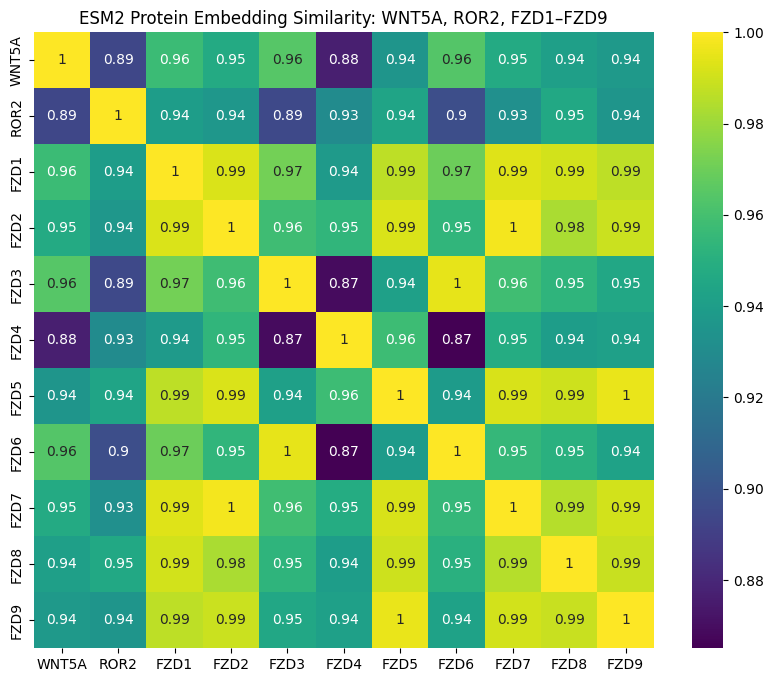

In [4]:
# ================================================
# 5. Visualization + Save as PDF
# ================================================
plt.figure(figsize=(10,8))
sns.heatmap(df, annot=True, cmap="viridis")
plt.title("ESM2 Protein Embedding Similarity: WNT5A, ROR2, FZD1–FZD9")

# Save as high-quality PDF (also works for PNG, SVG, etc.)
plt.savefig("WNT5A_ROR2_FZD_ESM2_similarity.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()